In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pprint

In [2]:
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    entropy_value = -np.sum([
        (counts[i] / np.sum(counts)) * np.log2(counts[i] / np.sum(counts))
        for i in range(len(elements))
    ])
    return entropy_value

In [3]:
def information_gain(data, feature, target="Class"):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = np.sum([
        (counts[i] / np.sum(counts)) *
        entropy(data[data[feature] == values[i]][target])
        for i in range(len(valuefnames))
    ])

    return total_entropy - weighted_entropy

In [66]:
def id3(data, original_data, features, target="Class", parent_node_class=None):
    
    # If only 1 category left
    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]

    # If no data left inside the tree, return majority
    if len(data) == 0:
        return np.unique(original_data[target])[np.argmax(np.unique(original_data[target], return_counts=True)[1])]

    # If no more features are available to classify, return parent
    if len(features) == 0:
        return parent_node_class
    
    parent_node_class = np.unique(data[target])[np.argmax(np.unique(data[target], return_counts=True)[1])]

    gains = [information_gain(data, feature, target) for feature in features]
    best_feature = features[np.argmax(gains)]
    
    tree = {best_feature: {}}
    features = [f for f in features if f != best_feature]

    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]
        subtree = id3(subset, original_data, features, target, parent_node_class)
        tree[best_feature][value] = subtree

    return tree

In [84]:
filename, target = 'iris.csv', "species"

In [85]:
data = pd.read_csv(filename)

In [86]:
features = list(data.columns[:-1])
tree = id3(data, data, features, target=target)
pprint.pprint(tree)

{'petal_length': {np.float64(1.0): 'setosa',
                  np.float64(1.1): 'setosa',
                  np.float64(1.2): 'setosa',
                  np.float64(1.3): 'setosa',
                  np.float64(1.4): 'setosa',
                  np.float64(1.5): 'setosa',
                  np.float64(1.6): 'setosa',
                  np.float64(1.7): 'setosa',
                  np.float64(1.9): 'setosa',
                  np.float64(3.0): 'versicolor',
                  np.float64(3.3): 'versicolor',
                  np.float64(3.5): 'versicolor',
                  np.float64(3.6): 'versicolor',
                  np.float64(3.7): 'versicolor',
                  np.float64(3.8): 'versicolor',
                  np.float64(3.9): 'versicolor',
                  np.float64(4.0): 'versicolor',
                  np.float64(4.1): 'versicolor',
                  np.float64(4.2): 'versicolor',
                  np.float64(4.3): 'versicolor',
                  np.float64(4.4): 'versicolor',
       

In [24]:
filename, target = 'drug.csv', 'Drug'

In [79]:
filename, target = 'instance.csv', 'class'

In [27]:
# CART Regression Tree

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree

import pydotplus
from IPython.display import Image

In [68]:
df = pd.read_csv('petrol_consumption.csv')

In [69]:
target = "Petrol_Consumption"
X = df.drop(columns=[target])
y = df[target]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [71]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l


Confusion Matrix:


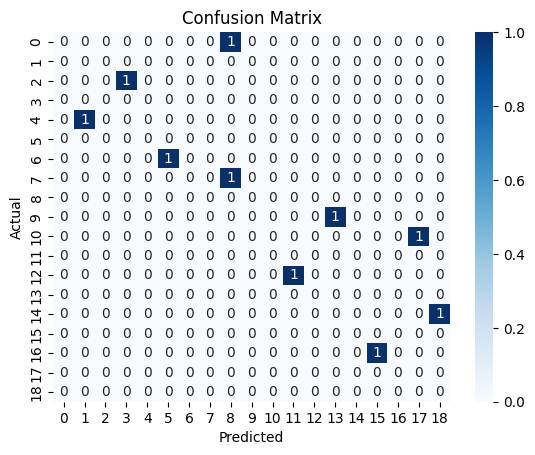

In [78]:
y_pred = model.predict(X_test)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

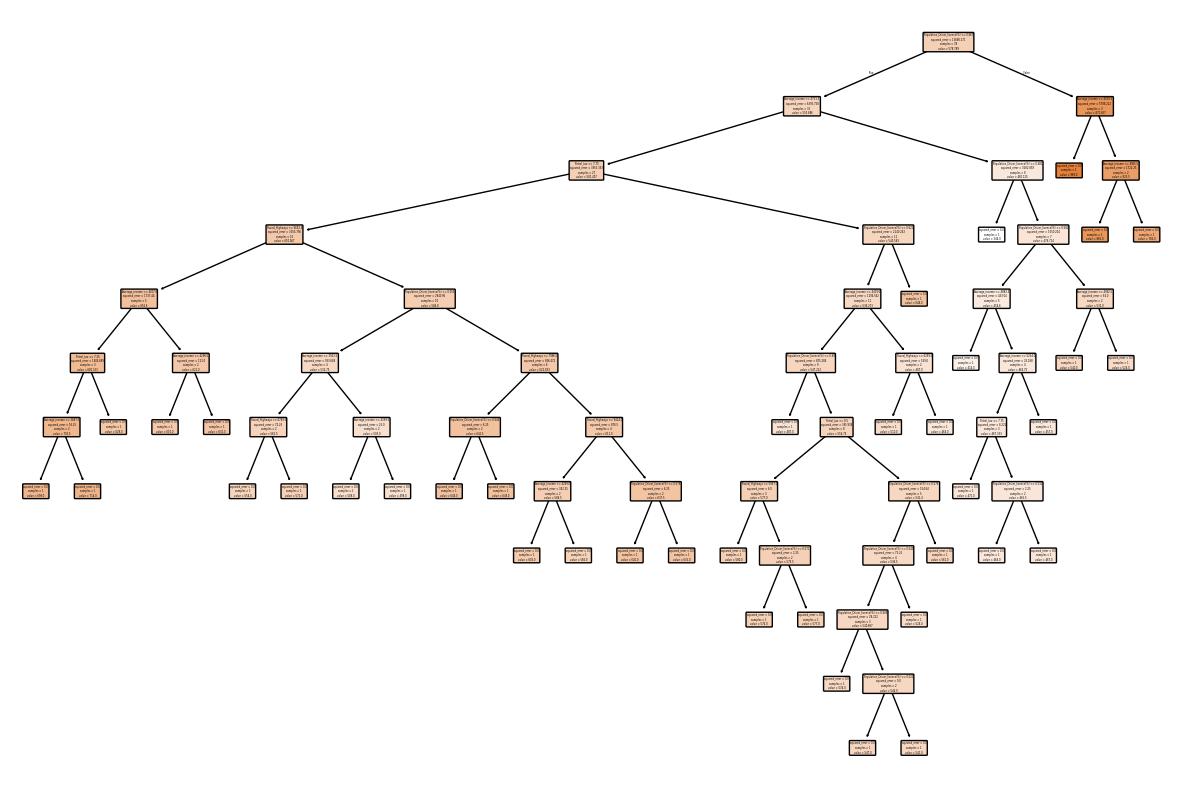

In [73]:
plt.figure(figsize=(15,10))
tree.plot_tree(
    model,
    feature_names=df.columns,
    filled=True,
    rounded=True,
)
plt.savefig("tree.png")
plt.show()